<a href="https://colab.research.google.com/github/Arczisork/Sztuczna-inteligencja/blob/main/sztuczna_lab_zad2a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)



2.19.0


In [66]:
observations = 100000
xs = np.random.uniform(low=-10,high=10,size=(observations,1))
zs = np.random.uniform(low=-10,high=10,size=(observations,1))
inputs=np.column_stack((xs,zs))
print(inputs.shape)


(100000, 2)


In [67]:
noise = np.random.uniform(low=-1,high=1,size=(observations,1))
targets = 2*xs - 3*zs + 5 + noise
np.savez('TF_dataset',inputs=inputs,targets=targets)
print(targets.shape)


(100000, 1)


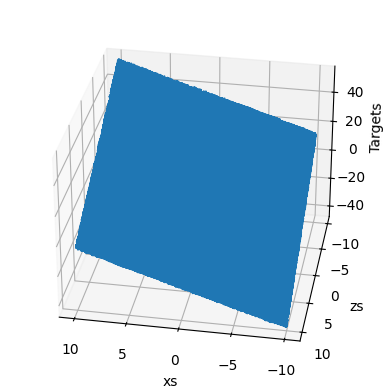

In [68]:

targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.plot(xs,zs,targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [69]:
init_range= 0.1
weights = np.random.uniform(low=-init_range,high=init_range,size=(2,1))
biases = np.random.uniform(low=-init_range,high=init_range,size=1)
print(weights,biases)


[[ 0.07189457]
 [-0.04841009]] [0.02510097]


In [70]:
targets = targets.reshape(observations,1)
eta = 0.0001
for i in range (100):
  outputs = np.dot(inputs,weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas **2)/2/observations
  print(loss)

  deltas_scaled = deltas/observations
  weights = weights - eta * np.dot(inputs.T,deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)


219.12008247517298
217.74651760595057
216.38205268938455
215.02662733546228
213.680181554958
212.3426557567731
211.0139907452938
209.69412771776666
208.38300826169095
207.08057435222898
205.7867683496333
204.5015329966906
203.2248114161836
201.95654710836854
200.69668394847028
199.44516618419394
198.20193843325256
196.9669456809117
195.74013327754986
194.5214469362357
193.3108327303207
192.10823709104835
190.9136068051786
189.7268890126288
188.54803120412953
187.37698121889682
186.21368724231877
185.0580978036588
183.91016177377307
182.76982836284327
181.63704711812534
180.51176792171142
179.39394098830874
178.28351686303117
177.18044641920716
176.08468085620112
174.9961716972497
173.91487078731245
172.84073029093665
171.77370269013593
170.71374078228413
169.66079767802157
168.6148267991766
167.5757818766998
166.5436169486131
165.51828635797122
164.49974475083758
163.48794707427356
162.48284857434024
161.4844047941147
160.49257157171846
159.50730503835945
158.52856161638692
157.5562980

In [71]:
print(weights, biases)

[[ 0.61629608]
 [-0.88538151]] [0.0745869]


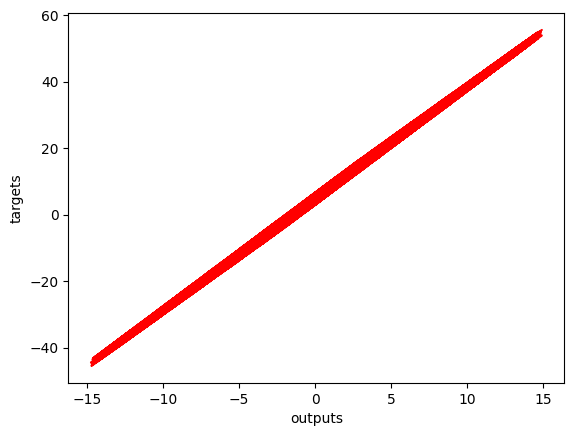

In [72]:
plt.plot(outputs, targets, color='red')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()